# Module Tutorial: Plotting

Because plotting will often involve plotting columns from data, the `smf.plot` module provides a set of wrappers for matplotlib.

These wrappers are generally fairly thin wrappers, allowing `DataSet`/`DataSetList` and `Column`s to be passed, instead of the arrays required by matplotlib.
In general, if a keyword argument is not passed by the user, the underlying matplotlib function receives no additional keyword argumnet.
The one key addition is the setting of axis labels, automatically based on the column's names.

The general format for these wrappers is:

`smf.plot.func(data, [colx, ...], gate=None, ax=None, **kwargs)`

Where 
- `data` is the `DataSet`/`DataSetList` source of the data(typcially the sublcasses `PhotonDataSet` or `PhotonDataList`).
- `colx, ...` is a certain number of `Column` objects, the number varies depending on the type of plot, 
  1 for histogram-like plots, 2 for scatter-plot-like.
- `gate`, if specified, regates all `colx,...` arguments to `gate`, otherwise, the gates of each column are `&` together.
- `ax` is the matplotlib [axes](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html) in which to plot.
- `**kwargs` Most kwargs are passed on to the underlying matplotlib functions.
  There are a number of additional kwargs for how to set the labels, and some plot specific kwargs, these will be addressed later

These functions also generally return whatever the underlying matplotlib function returns.
Since the the axes labels are also returned, the smfBursts functions usually return a tuple of these objects,
in the form of `axreturn, xlbl, ylbl`.

> **Recomendation**
>
> matplotlib (and by extension this module) is very easy to begin.
> But fully leveraging it's power takes a long time, as it is a very deep library.
> This results in people copy-pasting code without really understanding it.
>
> The most important thing to understand is how to specify the columns and gate of any given plotting function.
>
> Don't just blindly copy paste first arguments (data, colx, coly, gate), make sure you understand those,
> otherwise your plots might be plotting something other than what you think.
>
> However, if you like the style of a given plot, copy pasting the remaining parts should be fine.
> It is always best to understand the inputs, and there is no guarantee there won't be a mistake,
> but usually it is fine.

First let's import some data to plot, and then we'll see how plotting works.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf

# load raw data
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)
data.irf_thresh = {smf.PhSel('0ex0em'):2377, smf.PhSel('0ex1em'):2377, smf.PhSel('1ex1em'):246}

bg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, tail_min=5e-4, auto_threshold=True)
bs = smf.fretfactory.make_burst_search(bg=bg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))
bs['NanomeanDD'] = smf.Column(bs['bursts'], 'nanomean', smf.PhSel('0ex0em'))
bs['NanomeanDA'] = smf.Column(bs['bursts'], 'nanomean', smf.PhSel('0ex1em'))
gFret = smf.make_geq_gate(bs['NphDex_bg'], 40) & smf.make_geq_gate(bs['NphAA_bg'], 20)

## 1 Column Plots


### Basic Histograms

The functions for plotting histograms are:
1. `smf.plot.hist_bar()` uses [ax.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)
2. `smf.plot.hist_stair()` uses [ax.stairs](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.stairs.html)
3. `smf.plot.hist_line()` uses [ax.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)

The return values are always a tuple of `hist, bins, axreturn, xlbl, ylbl`
where 

- `hist` is the computed histogram (numpy array)
- `bins` are the bins of the computed histogram (numpy array, size 1 larger than `hist`)
- `axreturn` is the return value of the respective matplotlib function
- `xlbl` is the [plt.Text](https://matplotlib.org/stable/api/text_api.html#matplotlib.text.Text) object of the xlabel
- `ylbl` is the [plt.Text](https://matplotlib.org/stable/api/text_api.html#matplotlib.text.Text) object of the ylabel


In the example below, also note how bins can be set as a keyword argument, 
and additional kwargs like `ec` for setting the edge color of the bars are passed on to
[ax.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)

(array([ 20,  44,  64,  95, 133, 145, 190, 182, 154, 155, 125, 105,  87,
         85,  66,  54,  45,  51,  43,  53,  49,  45,  33,  28,  31,  32,
         39,  31,  27,  26,  30,  29,  27,  27,  24,  17,  16,  14,  15,
         13,   9,   6,  10,  10,   1,   1,   1,   0,   0,   0]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>,
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, '# Bursts'))

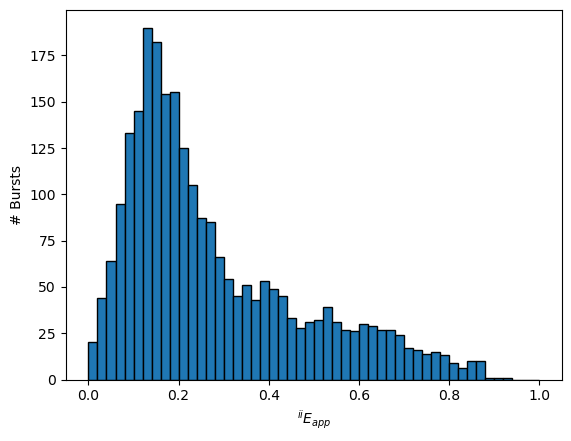

In [2]:
smf.plot.hist_bar(data, bs['E_bg'], bins=np.linspace(0,1,51), gate=gFret, ec='k')

These all have an orientation keyword argument to re-orient the plotting axis either `'vertical'` for a normal bar chart, or `'horizontal'` for the bars to go horizontally.

(array([ 20,  44,  64,  95, 133, 145, 190, 182, 154, 155, 125, 105,  87,
         85,  66,  54,  45,  51,  43,  53,  49,  45,  33,  28,  31,  32,
         39,  31,  27,  26,  30,  29,  27,  27,  24,  17,  16,  14,  15,
         13,   9,   6,  10,  10,   1,   1,   1,   0,   0,   0]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 Text(0.5, 0, '# Bursts'),
 Text(0, 0.5, '$^{ii}E_{app}$'))

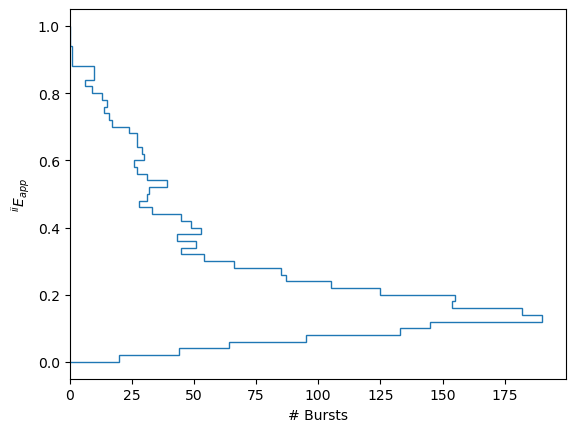

In [3]:
smf.plot.hist_stair(data, bs['E_bg'], bins=np.linspace(0,1,51), gate=gFret, orientation='horizontal')

There are also several options for normalization of the histogram.
Normalization is specified through the `normalize` keyword argument.

The options are: 

- `'none'`: no normalization, values are raw counts in each bin (default)
- `'sum'` sum of all bins = 1.
- `'max'` the bin with the largest counts is equal to 1 (max = 1).
- `'PDF'` probability density function, the area under the histogram is 1.
- `'cumulative'` histogram is cumulative counts
- `'icumulative'` histogram is inverse cumulative counts (cumulative starting from max instead of min)
- `'CDF'` cumulative density function
- `'iCDF'` inverse cumulative density function

(array([0.00804182, 0.017692  , 0.02573382, 0.03819863, 0.05347809,
        0.05830318, 0.07639727, 0.07318054, 0.06192199, 0.06232409,
        0.05026136, 0.04221954, 0.03498191, 0.03417772, 0.026538  ,
        0.02171291, 0.01809409, 0.02050663, 0.01728991, 0.02131082,
        0.01970245, 0.01809409, 0.013269  , 0.01125854, 0.01246482,
        0.01286691, 0.01568154, 0.01246482, 0.01085645, 0.01045436,
        0.01206273, 0.01166064, 0.01085645, 0.01085645, 0.00965018,
        0.00683554, 0.00643345, 0.00562927, 0.00603136, 0.00522718,
        0.00361882, 0.00241255, 0.00402091, 0.00402091, 0.00040209,
        0.00040209, 0.00040209, 0.        , 0.        , 0.        ]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.

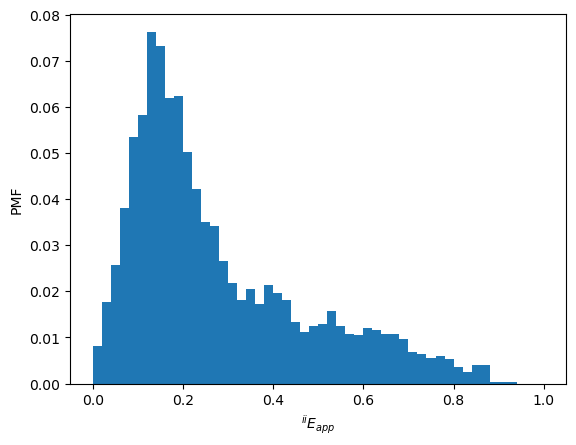

In [4]:
smf.plot.hist_bar(data, bs['E_bg'], bins=np.linspace(0,1,51), gate=gFret, normalize='sum')

### KDE plots

Another method for plotting the distribution of values of a single column is computing the kernel density estimator.

This can be done with the `smf.plot.kdeplot` function (which can also be used to plot 2D KDEs, 
which will be handled leter in the [2D smf.plot.kdeplot](#2D-smf.plot.kdeplot) section).

([<matplotlib.lines.Line2D at 0x75b07dcb7620>],
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, 'PDF'))

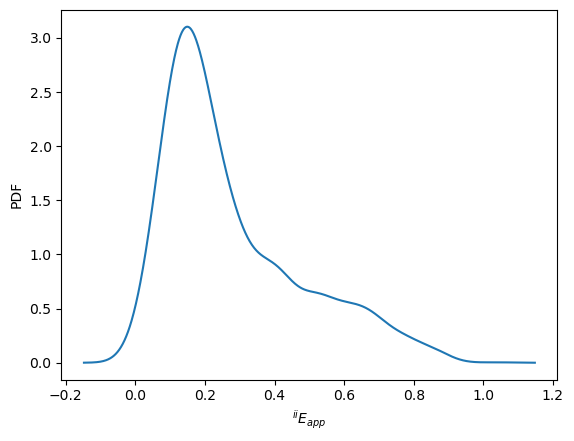

In [5]:
smf.plot.kdeplot(data, bs['E_bg'], gate=gFret)

The KDE is computed with [scipy.stats.gaussian_kde](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html).
The `bw_method` and `weights` keyword arguments are passed on to this function.

([<matplotlib.lines.Line2D at 0x75b07db103e0>],
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, 'PDF'))

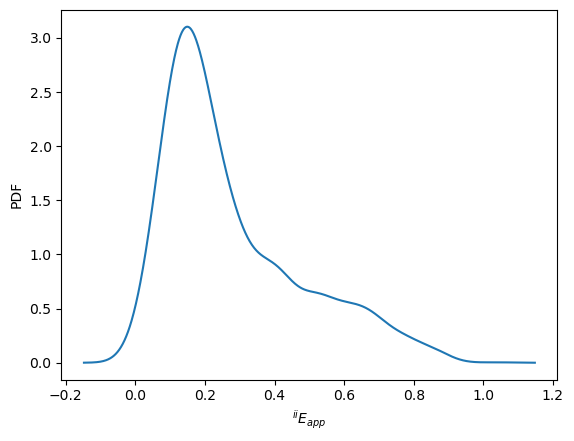

In [6]:
smf.plot.kdeplot(data, bs['E_bg'], gate=gFret, bw_method='scott')

In the 1-D form, by default, `smf.kdeplot` uses [ax.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html),
and the kwargs (except `bw_method` and `weigths`) are passed on to the 
[ax.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html) function.

([<matplotlib.lines.Line2D at 0x75b07d770e90>],
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, 'PDF'))

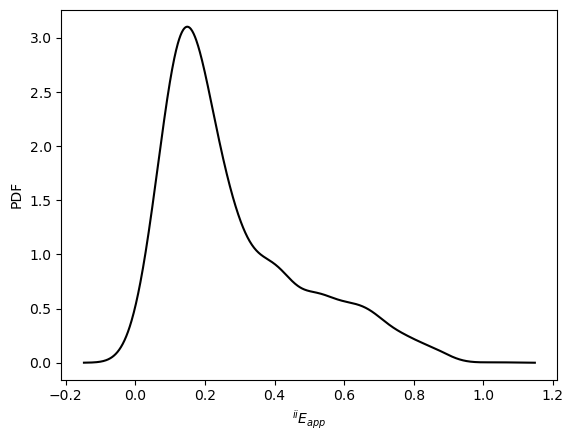

In [7]:
smf.plot.kdeplot(data, bs['E_bg'], gate=gFret, c='k')

It not not uncommon to plot the KDE and histogram overlayed over each other.
However, when doing so using separate function calls, it can be difficult to ensure the normalization of the histogram matches the scale of the KDE.

Therefore smfbursts provides the function `smf.plot.hist_kdeoverlay` which ensures matching normalizations.

(array([  1,   2,   7,   4,  11,  13,  24,  31,  39,  46,  51,  70,  75,
         81,  81, 105,  95, 107,  76,  81,  92,  82,  74,  69,  57,  59,
         39,  49,  49,  38,  39,  27,  30,  33,  20,  27,  28,  22,  26,
         27,  31,  25,  26,  25,  17,  21,  14,  16,  14,  18,  18,  19,
         26,  13,  16,  19,  13,  16,  11,  19,  14,  13,  18,  12,  17,
          9,  20,  15,  10,  10,   9,   8,   9,   4,   7,   9,   9,   6,
          5,   3,   4,   3,   4,   7,   6,   1,   1,   1,   0,   1,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   1]),
 array([-0.03961346, -0.02881787, -0.01802229, -0.00722671,  0.00356887,
         0.01436445,  0.02516003,  0.03595561,  0.04675119,  0.05754677,
         0.06834235,  0.07913793,  0.08993352,  0.1007291 ,  0.11152468,
         0.12232026,  0.13311584,  0.14391142,  0.154707  ,  0.16550258,
         0.17629816,  0.18709374,  0.19788933,  0.20868491,  0.21948049,
         0.23027607,  0.24107165,  0.25186723,  0.26266281,  0.273458

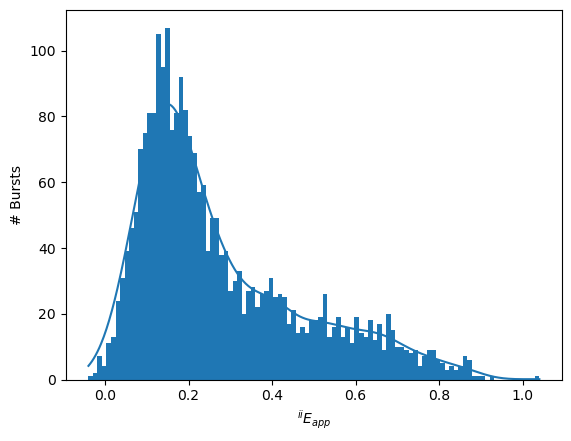

In [8]:
smf.plot.hist_kdeoverlay(data, bs['E_bg'], gate=gFret)

The standard keyword arguments are passed to the histogram plotting function, while the keyword arguments for the kde plotting function should be passed to `kdeplot_kwargs`

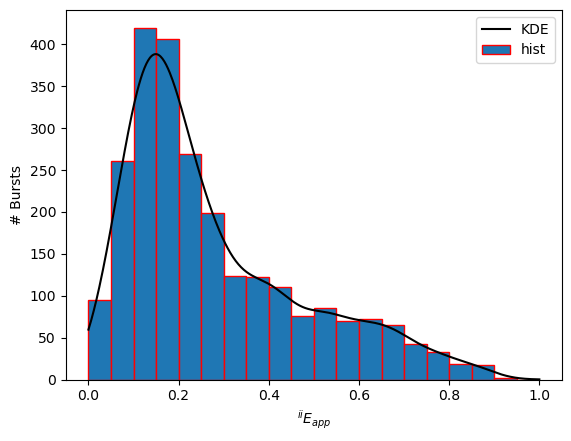

In [9]:
smf.plot.hist_kdeoverlay(data, bs['E_bg'], gate=gFret, kdeplot_kwargs={'c':'k', 'label':'KDE'}, bins=np.linspace(0, 1.0, 21), ec='r', label='hist')
plt.legend()

## 2D plots

For plotting 2D data, there are the following "standard" ways to visualize such data:

1. `smf.plot.scatter` uses [ax.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html)
2. `smf.plot.hist2d` uses [ax.hist2d](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist2d.html)
3. `smf.plot.hexbin` uses [ax.hexbin](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hexbin.html)

below is an example of plotting the same data with each of these functions 
(note the use of the `ax` keyword argument, and how other kwargs are specific to each plot):

(<matplotlib.collections.PolyCollection at 0x75b07d7c1910>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

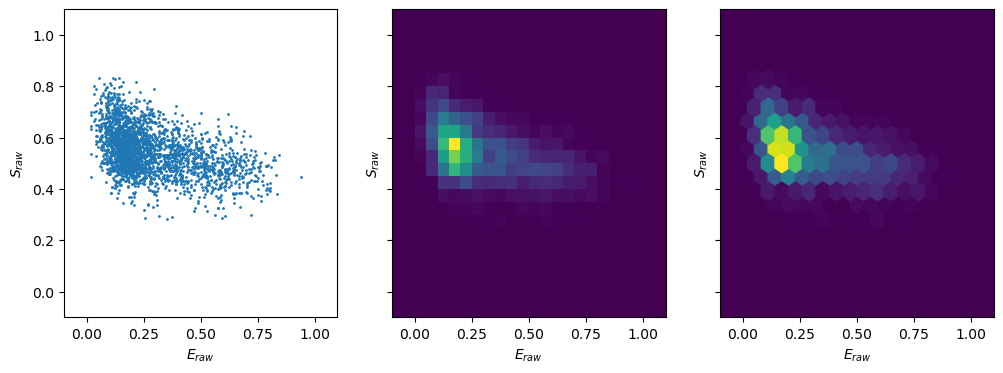

In [10]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharex=True, sharey=True)
smf.plot.scatter(data, bs['E_raw'], bs['S_raw'], gate=gFret, ax=ax[0], s=1.0)
smf.plot.hist2d(data, bs['E_raw'], bs['S_raw'], gate=gFret, ax=ax[1], bins=(np.linspace(-0.1, 1.1, 25), np.linspace(-0.1, 1.1, 25)))
smf.plot.hexbin(data, bs['E_raw'], bs['S_raw'], gate=gFret, ax=ax[2], gridsize=20, extent=(-0.1, 1.1, -0.1, 1.1))

### Scatter `point_func` kwarg

`smf.plot.scatter` has a special keyword argument `point_func` this is used for creating row-specific point control.
The most common useage is shown below, where the input of `smf.plot.density_kde` colors points based on proximity to others:

(<matplotlib.collections.PathCollection at 0x75b07db9e390>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

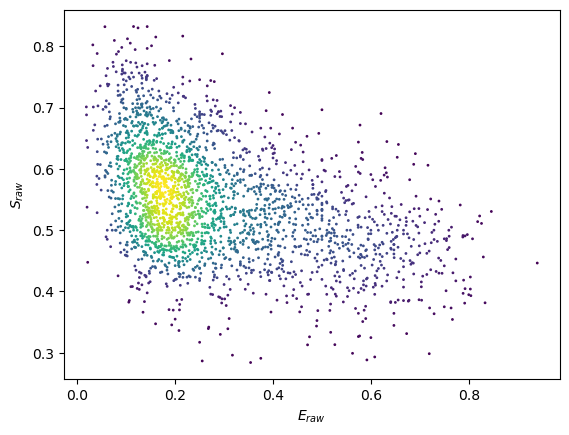

In [11]:
smf.plot.scatter(data, bs['E_raw'], bs['S_raw'], gate=gFret, point_func=smf.plot.density_kde, s=1.0)

`point_func` must be a callable with a specific signature of `point_func(colxarr, colyarr, *point_colarrs, **point_kwargs)`

Where:
- `colxarr` and `colyarr` are the data points of the `colx` and `coly` arguments of `smf.plot.scatter()`
- `point_colarrs` are the data points from the columns passed to `point_cols` keyword argument passed to `smf.plot.scatter()`
  If None (default), no additional column arrays are passed, if `point_cols` is specified as a single `Column`, then
  pass a single additional array, or `point_cols` can be a sequence of `Column` objects, in which case each is passed
  as the array of data points for each `Column` object.
  Note that depending on the function passed to `point_func`, a specific number of `Column` objects may need to be passed
- `point_kwargs` is the dictonary passed to the `point_kwargs` argument of `smf.plot.scatter()`


The `smf.plot.density_kde` function accepts no `point_cols`, but the `density_size` function relies on a single `point_cols` column
to set the size of each point, based on the column passed to `density_size`:

(<matplotlib.collections.PathCollection at 0x75b07dd49e20>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

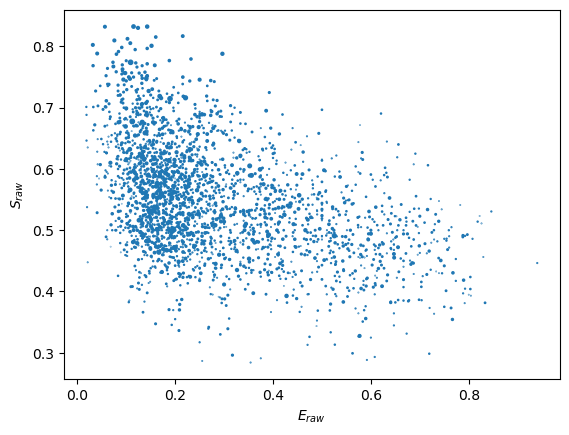

In [12]:
smf.plot.scatter(data, bs['E_raw'], bs['S_raw'], gate=gFret, 
                 point_func=smf.datamodel.plot.point_size, point_cols=bs['NphDex_raw'], 
                 point_kwargs={'scale_factor':10})

This tutorial will not go into a detailed explanation of each function.
Consult the documentation on each particular function.
There are additional function, which will generally have a note in their description something like:
"Function to use as value of `point_func` kwarg in `scatter()`"
These functions are typically named either `point_...` or `density_...`

The functions all work by returning a dictionary that is used to update the kwargs that are finally passed to the `ax.scatter()`.

Below is an example function that sets the color of the marker based on the point_cols column:

(<matplotlib.collections.PathCollection at 0x75b07e18cfe0>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

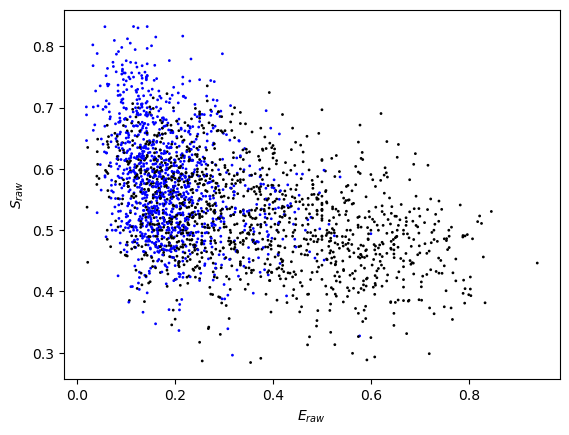

In [13]:
def point_cthresh(cx, cy, ccolor, thresh=50, clow='k', chigh='b'):
    return {'c':[clow if c < thresh else chigh for c in ccolor]}


smf.plot.scatter(data, bs['E_raw'], bs['S_raw'], gate=gFret, point_func=point_cthresh, point_cols=bs['NphDD_raw'], s=1.0)

### 2D `smf.plot.kdeplot`

When `smf.plot.kdeplot` is given 2 columns, a 2d heatmap is plotted.
`gaus_2Dkde_cmap` is used to generate the KDE.
When no `sigmax`, `sigmay`, or `rho` arguments are supplied, it functions essentially the same as 
[scipy.stats.gaussian_kde](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html).
The `thresh` argument can be used to set the minimum value of the KDE for the color not to be transparent.
If `thresh_raw=False` (default), then this is a fraction from 0 to 1, otherwise a raw value is used.

(None, Text(0.5, 0, '$E_{raw}$'), Text(0, 0.5, '$S_{raw}$'))

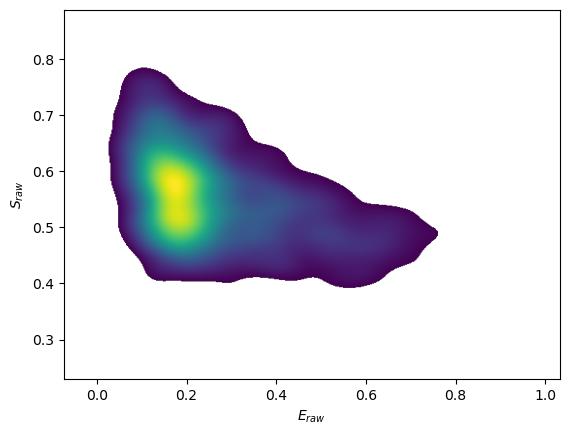

In [14]:
smf.plot.kdeplot(data, bs['E_raw'], bs['S_raw'], gate=gFret, thresh=0.1)

Below we use both `smf.plot.kdeplot` and `smf.plot.scatter` to overlay the KDE with the actual bursts.
This can be useful to show both the raw data and give a sense of the overal density in a region.

(<matplotlib.collections.PathCollection at 0x75b07db48ce0>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

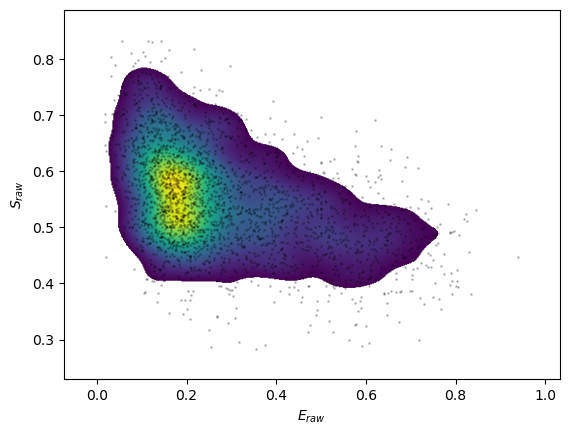

In [15]:
smf.plot.kdeplot(data, bs['E_raw'], bs['S_raw'], gate=gFret, thresh=0.1)
smf.plot.scatter(data, bs['E_raw'], bs['S_raw'], gate=gFret, s=1.0, alpha=0.2, c='k')

## Standard Kwargs

Most of the plotting functions have a set of kwargs that are not passed to the matplotlib function,
but rather used for setting labels and rescaling.
Their standard names are:

- `include_unit` indicates whether to include the unit label in the axis labels
- `rescale` specifies the rescale factor
- `x/ylabel` how and whether to set the x/y label
- `x/ylabel_kwargs` kwargs passed to `ax.set_x/ylabel`

### `include_unit` kwarg

The `include_unit` kwarg is probably the simplest to understand of the standard kwargs.

It is simply a boolean, and indicates whether or not to include a units label in axis label.

For 2-D plots, it can also be specified as a 2-tuple, if units are desired for 1 axis but not the other.

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(50, 50)),
 array([0.0e+00, 2.0e-10, 4.0e-10, 6.0e-10, 8.0e-10, 1.0e-09, 1.2e-09,
        1.4e-09, 1.6e-09, 1.8e-09, 2.0e-09, 2.2e-09, 2.4e-09, 2.6e-09,
        2.8e-09, 3.0e-09, 3.2e-09, 3.4e-09, 3.6e-09, 3.8e-09, 4.0e-09,
        4.2e-09, 4.4e-09, 4.6e-09, 4.8e-09, 5.0e-09, 5.2e-09, 5.4e-09,
        5.6e-09, 5.8e-09, 6.0e-09, 6.2e-09, 6.4e-09, 6.6e-09, 6.8e-09,
        7.0e-09, 7.2e-09, 7.4e-09, 7.6e-09, 7.8e-09, 8.0e-09, 8.2e-09,
        8.4e-09, 8.6e-09, 8.8e-09, 9.0e-09, 9.2e-09, 9.4e-09, 9.6e-09,
        9.8e-09, 1.0e-08]),
 array([0.0e+00, 2.0e-10, 4.0e-10, 6.0e-10, 8.0e-10, 1.0e-09, 1.2e-09,
        1.4e-09, 1.6e-09, 1.8e-09, 2.0e-09, 2.2e-09, 2.4e-09, 2.6e-09,
        2.8e-09, 3.0e-09, 3.2e-09, 3.4e-09, 3.6e-09, 3.8e-09, 4.0e-0

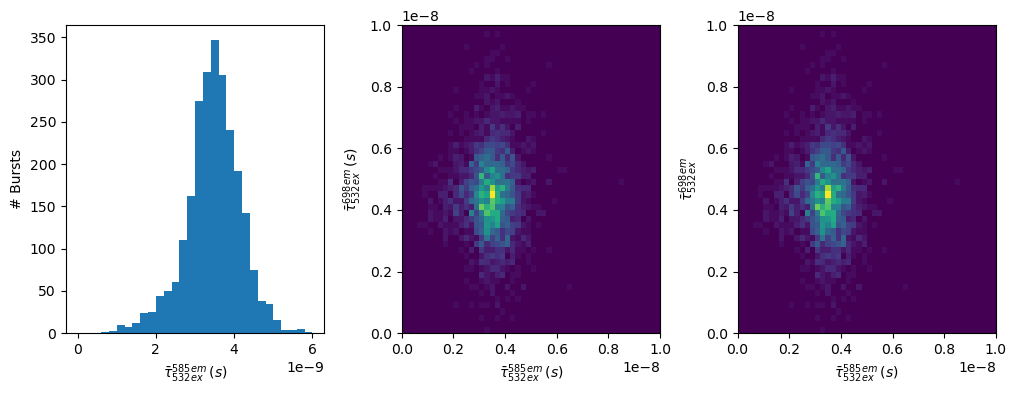

In [16]:
fig, ax = plt.subplots(1,3, figsize=(12,4), gridspec_kw={'wspace':0.3})
bins=np.linspace(0,6e-9, 31)
bins2d = (np.linspace(0,1e-8, 51), np.linspace(0,1e-8, 51))

smf.plot.hist_bar(data, bs['NanomeanDD'], gate=gFret, bins=bins, include_unit=True, ax=ax[0])
smf.plot.hist2d(data, bs['NanomeanDD'], bs['NanomeanDA'], gate=gFret, bins=bins2d, include_unit=True, ax=ax[1])
smf.plot.hist2d(data, bs['NanomeanDD'], bs['NanomeanDA'], gate=gFret, bins=bins2d, include_unit=(True, False), ax=ax[2])

### `rescale` kwarg

The rescale kwarg is best used for setting the magnitude of a column.
It can be specified either as an integral value, or as a floating point value.
In general, rescale is used for time-based columns, since time based columns have either units of 
measurement clock (and have integral values), or seconds (and have floating point values).
However, when plotting, for instance mean lifetimes, we typically want units of nanoseconds,
or for burst durations, units of milliseconds.

Here rescale comes to the rescue.
For 1-D distributions, rescale is specified either as an integral value (`int`), or floating point value (`float`)

Integral and floating values are handled differently.
(smfBursts tests the type, and uses a different function for each).
If specified as an integer value, the rescale is treated as a power of 10, and the value of the column is multiplied by $10^{rescale}$.
So, to convert from seconds to nanoseconds, we would specify a rescale value of -9.

On the other hand, if it is a floating point, the column is multiplied by the value itself.
So specifying `rescale=1e-9` is equivalent to specifying `rescale=-9`.
This of course means that specifying with floating points give more flexibility, however,
with integers it is probably more clear.

Below is an example of how to plot a histogram of the mean lifetime of a burst in units of nanoseconds

(array([  0,   0,   0,   1,   3,  10,   7,  12,  24,  25,  44,  50,  61,
        110, 162, 275, 309, 347, 305, 240, 192, 142,  75,  38,  35,  15,
          4,   4,   5,   1]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4,
        2.6, 2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. ,
        5.2, 5.4, 5.6, 5.8, 6. ]),
 <BarContainer object of 30 artists>,
 Text(0.5, 0, '$\\bar \\tau_{532ex}^{585em}\\: (ns)$'),
 Text(0, 0.5, '# Bursts'))

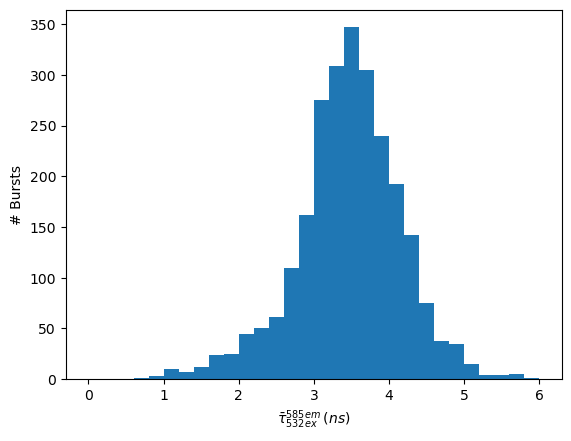

In [17]:
smf.plot.hist(data, bs['NanomeanDD'], bins=np.linspace(0, 6, 31), gate=gFret, include_unit=True, rescale=-9)

For 2-D distributions, `rescale` works similar to `include_unit`, in that the value can be specified either
as a single value for both columns, or as a 2-tuple, one value for x, the other for y.

Below is an example of a classic $E-\tau$ plot, note the rescale of the $\tau$ value is -9 and of $E$ is 0.

(0.0, 1.0)

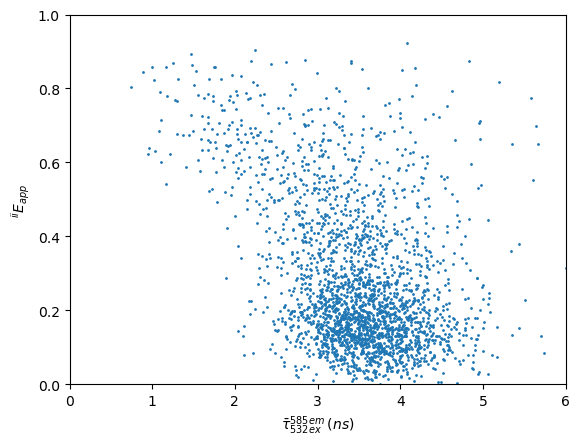

In [18]:
smf.plot.scatter(data, bs['NanomeanDD'], bs['E_bg'], gate=gFret, s=1.0, rescale=(-9, 0))
plt.xlim([0,6.0])
plt.ylim([0,1.0])

In [19]:
bs['NanomeanDD'].name(include_unit=True, origin=data)

'$\\bar \\tau_{532ex}^{585em}\\: (s)$'

## `x/ylabel` kwarg

By default, the x and y labels (and units) are set by using the `Column` method
`col.name` method (called as `col.name(include_unit=include_unit, origin=data)`)

This behavior can be overridden by the `x/ylabel` keyword argument.
The options are either `False` or a string (the default is `None`, so specifying `xlabel=None` will give the same result as not specifying `xlabel`).

If `False`, then `ax.set_x/ylabel` will not be called.
If the respective label is kwarg is specified as a string, that string will be used instead of the `col.name` label.
(Note that specifying as a string overrides the `include_unit` kwarg).

The `x/ylabel_kwargs` are very simple, they simply pass the dictionary handed to them as kwargs to
[ax.set_xlabel](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_xlabel.html)
or 
[ax.set_ylabel](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_ylabel.html).

Below we can see how specifying xlabel as a string lets us use the older nomenclature for background corrected
ratio of FRET to donor emission, proximity ratio.

(array([  0,   0,   0,   3,   9,  20,  44,  64,  95, 133, 145, 190, 182,
        154, 155, 125, 105,  87,  85,  66,  54,  45,  51,  43,  53,  49,
         45,  33,  28,  31,  32,  39,  31,  27,  26,  30,  29,  27,  27,
         24,  17,  16,  14,  15,  13,   9,   6,  10,  10,   1,   1,   1,
          0,   0,   0,   0,   1,   0,   0,   0]),
 array([-1.00000000e-01, -8.00000000e-02, -6.00000000e-02, -4.00000000e-02,
        -2.00000000e-02,  1.38777878e-17,  2.00000000e-02,  4.00000000e-02,
         6.00000000e-02,  8.00000000e-02,  1.00000000e-01,  1.20000000e-01,
         1.40000000e-01,  1.60000000e-01,  1.80000000e-01,  2.00000000e-01,
         2.20000000e-01,  2.40000000e-01,  2.60000000e-01,  2.80000000e-01,
         3.00000000e-01,  3.20000000e-01,  3.40000000e-01,  3.60000000e-01,
         3.80000000e-01,  4.00000000e-01,  4.20000000e-01,  4.40000000e-01,
         4.60000000e-01,  4.80000000e-01,  5.00000000e-01,  5.20000000e-01,
         5.40000000e-01,  5.60000000e-01,  5.80000

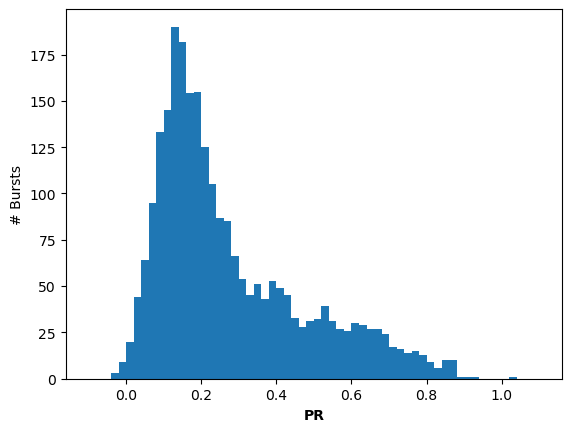

In [20]:
# specify xlabel as string
smf.plot.hist_bar(data, bs['E_bg'], gate=gFret, bins=np.linspace(-0.1,1.1,61), 
                  xlabel='PR', # manually set xlabel string
                  xlabel_kwargs={'fontweight':'bold'}) # use xlabel_kwargs to make font bold in x-axis label

If `xlabel=False` the label is not set:

(array([  0,   0,   0,   3,   9,  20,  44,  64,  95, 133, 145, 190, 182,
        154, 155, 125, 105,  87,  85,  66,  54,  45,  51,  43,  53,  49,
         45,  33,  28,  31,  32,  39,  31,  27,  26,  30,  29,  27,  27,
         24,  17,  16,  14,  15,  13,   9,   6,  10,  10,   1,   1,   1,
          0,   0,   0,   0,   1,   0,   0,   0]),
 array([-1.00000000e-01, -8.00000000e-02, -6.00000000e-02, -4.00000000e-02,
        -2.00000000e-02,  1.38777878e-17,  2.00000000e-02,  4.00000000e-02,
         6.00000000e-02,  8.00000000e-02,  1.00000000e-01,  1.20000000e-01,
         1.40000000e-01,  1.60000000e-01,  1.80000000e-01,  2.00000000e-01,
         2.20000000e-01,  2.40000000e-01,  2.60000000e-01,  2.80000000e-01,
         3.00000000e-01,  3.20000000e-01,  3.40000000e-01,  3.60000000e-01,
         3.80000000e-01,  4.00000000e-01,  4.20000000e-01,  4.40000000e-01,
         4.60000000e-01,  4.80000000e-01,  5.00000000e-01,  5.20000000e-01,
         5.40000000e-01,  5.60000000e-01,  5.80000

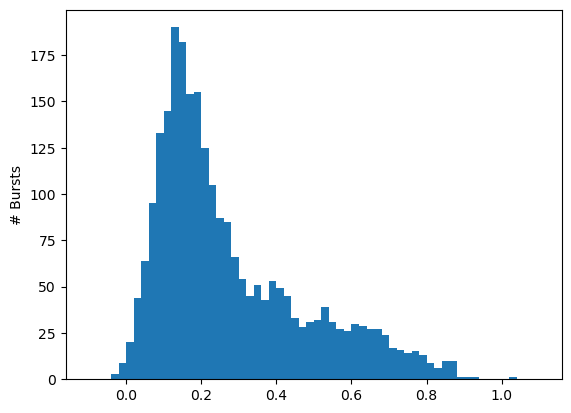

In [21]:
# specify xlabel as string
smf.plot.hist_bar(data, bs['E_bg'], gate=gFret, bins=np.linspace(-0.1,1.1, 61), xlabel=False)

The main reason to set a `x/ylabel=False` is when multiple plots are being overlayed together.

For instance, what if we plot the histograms of different populations?
The labels can be different, if `x/ylabel` were not set to `False`, then the label would be re-set each time a plot function is called.

Therefore, it is better to set the axis label separately, or by specifying `x/ylabel='general name'` on one call, and `x/ylabel=False` on subsequent calls.

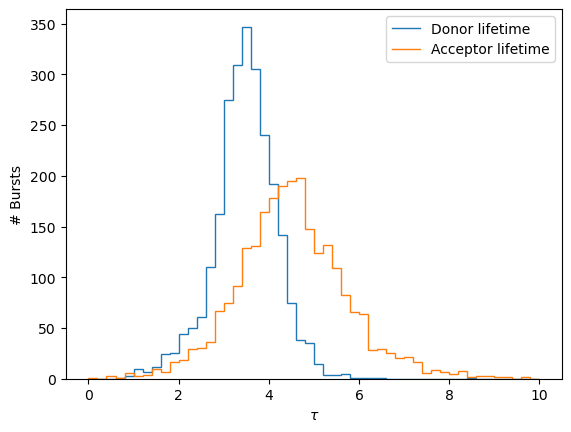

In [22]:
# label = False pattern for multiple overlayed distributions
smf.plot.hist_stair(data, bs['NanomeanDD'], gate=gFret,
                    bins=np.linspace(0,10,51), 
                    xlabel=False, # prevent any setting of xlabel
                    rescale=-9, label='Donor lifetime')
smf.plot.hist_stair(data, bs['NanomeanDA'], gate=gFret, 
                    bins=np.linspace(0,10,51), 
                    xlabel=r'$\tau$', # set xlabel to generic title
                    rescale=-9, label='Acceptor lifetime')
plt.legend()